# Regridding: atmosphere (SE to lat/lon)

CESM writes the atmosphere on a spectral-element grid (`ncol`). `.x.regrid()` maps it
onto a regular lat/lon grid. Weight files for the supported SE grids are looked up in
the user cache, then next to the package, and downloaded on demand if neither has
them — nothing about the call changes.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
ts_path = os.path.join(
    case_dir, 'atm', 'proc', 'tseries', 'month_1',
    f'{casename}.cam.h0.TS.000101-000512.nc',
)
ds = x4c.open_dataset(ts_path, comp='atm', grid='ne16np4', vn='TS', shift_time=True)

print('native  :', dict(ds.x.da.sizes))
ds_rgd = ds.x.regrid(dlon=2, dlat=2)
print('regridded:', dict(ds_rgd.x.da.sizes))

native  : {'time': 60, 'ncol': 13826}


regridded: {'time': 60, 'lat': 90, 'lon': 180}


## The area weight is re-derived, not carried over

This is the part worth understanding. The source weight (`area`, on `ncol`) does not
describe the output grid, so `regrid` replaces it with a weight for the target grid.
The consequence is that a global mean is consistent across the regrid, to within the
remapping error itself.

In [3]:
print('native gw dims    :', tuple(ds.attrs['gw'].dims))
print('regridded gw dims :', tuple(ds_rgd.attrs['gw'].dims))
print()

gm_native = float(ds.x.da.x.gm[0])
gm_rgd = float(ds_rgd.x.da.x.gm[0])
print(f'global mean, native grid    : {gm_native:.4f} K')
print(f'global mean, regridded      : {gm_rgd:.4f} K')
print(f'difference (remapping error): {gm_rgd - gm_native:+.4f} K')

native gw dims    : ('ncol',)
regridded gw dims : ('lat', 'lon')

global mean, native grid    : 294.8395 K
global mean, regridded      : 294.8384 K
difference (remapping error): -0.0011 K


Hemispheric means work after a regrid too, because the latitude metadata is
re-attached for the target grid.

In [4]:
print(f'NH mean after regrid: {float(ds_rgd.x.da.x.nhm[0]):.4f} K')
print(f'SH mean after regrid: {float(ds_rgd.x.da.x.shm[0]):.4f} K')

NH mean after regrid: 289.1330 K
SH mean after regrid: 300.5438 K


## Native versus regridded, side by side

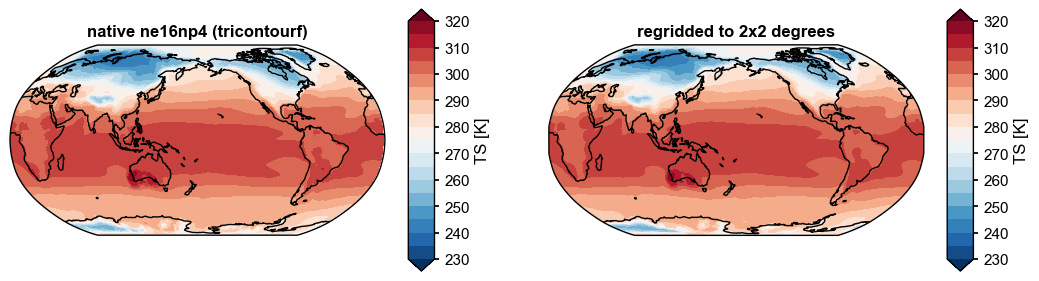

In [5]:
ax_loc = {'a': (0, 0), 'b': (0, 1)}
projs = {k: 'Robinson' for k in ax_loc}
projs_kws = {k: {'central_longitude': 180} for k in ax_loc}
fig, axd = x4c.subplots(1, 2, ax_loc=ax_loc, projs=projs, projs_kws=projs_kws,
                        figsize=(13, 3.4), wspace=0.15)

levels = np.linspace(230, 320, 19)
ds.x.da.isel(time=0).x.plot(ax=axd['a'], levels=levels,
                            title='native ne16np4 (tricontourf)')
ds_rgd.x.da.isel(time=0).x.plot(ax=axd['b'], levels=levels,
                                title='regridded to 2x2 degrees')
x4c.showfig(fig)